In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rcParams.update({'font.size': 16})

In [8]:
input_dim = 1
output_dim = 1

A = 2 * np.random.rand(output_dim, input_dim) - 1
b = 2 * np.random.rand(output_dim) - 1

true_model = lambda x: A @ x + b

In [9]:
n_train = 1000
noise_level = 0.04

X_train = np.random.rand(n_train, input_dim)
y_train = np.array([true_model(x) for x in X_train])
y_train += noise_level * np.random.standard_normal(size=y_train.shape)

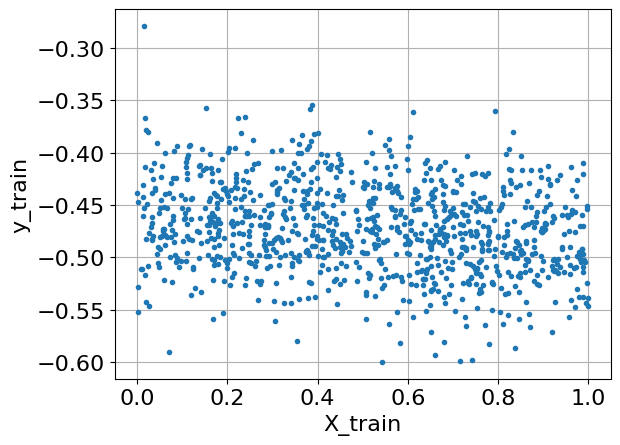

In [10]:
if input_dim == output_dim == 1:
    fig = plt.figure()
    fig.clf()
    ax = fig.gca()
    ax.plot(X_train, y_train, '.')
    ax.grid(True)
    ax.set_xlabel('X_train')
    ax.set_ylabel('y_train')

In [11]:
class VectorialDataset(torch.utils.data.Dataset):
    def __init__(self, input_data, output_data):
        super(VectorialDataset, self).__init__()
        self.input_data = torch.tensor(input_data.astype('f'))
        self.output_data = torch.tensor(output_data.astype('f'))
        
    def __len__(self):
        return self.input_data.shape[0]
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        sample = (self.input_data[idx, :], 
                  self.output_data[idx, :])  
        return sample 

In [12]:
training_set = VectorialDataset(input_data=X_train, output_data=y_train)

In [13]:
len(training_set)

1000

In [14]:
training_set[10:12]

(tensor([[0.5586],
         [0.8663]]),
 tensor([[-0.3975],
         [-0.5035]]))

In [15]:
batch_size = 120
train_loader = torch.utils.data.DataLoader(training_set, 
                                           batch_size=batch_size, 
                                           shuffle=True)

In [16]:
for idx, batch in enumerate(train_loader):
    print('Batch n. %2d: input size=%s, output size=%s' % (idx+1, batch[0].shape, batch[1].shape))

Batch n.  1: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  2: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  3: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  4: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  5: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  6: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  7: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  8: input size=torch.Size([120, 1]), output size=torch.Size([120, 1])
Batch n.  9: input size=torch.Size([40, 1]), output size=torch.Size([40, 1])


In [17]:
first_batch = []

for epoch in range(2):
    for idx, batch in enumerate(train_loader):
        if idx == 0:
            first_batch.append(batch)
        
np.c_[X_train[:batch_size], first_batch[0][0].numpy(), first_batch[1][0].numpy()]

array([[3.75810224e-01, 1.37259781e-01, 6.32783294e-01],
       [4.46474498e-01, 2.19656914e-01, 4.58962023e-01],
       [5.58036271e-01, 2.11759299e-01, 2.83084422e-01],
       [1.11259877e-01, 2.44916446e-04, 7.49067187e-01],
       [3.44976001e-01, 5.11810660e-01, 2.51963228e-01],
       [1.59724201e-01, 9.69500899e-01, 3.58115405e-01],
       [2.99871137e-01, 5.75974345e-01, 5.20559400e-02],
       [6.50591781e-01, 5.27279675e-01, 3.54851037e-01],
       [7.39078977e-01, 3.92998099e-01, 1.93197310e-01],
       [9.86964345e-01, 9.71104622e-01, 3.66509587e-01],
       [5.58625772e-01, 2.72253990e-01, 5.36683917e-01],
       [8.66305364e-01, 7.06774890e-01, 4.26699221e-01],
       [2.90558912e-01, 1.64866552e-01, 6.73438549e-01],
       [3.73975398e-01, 4.51728612e-01, 6.57963574e-01],
       [8.19190017e-01, 8.86146843e-01, 8.97834837e-01],
       [1.44855155e-01, 5.58604181e-01, 6.08365610e-02],
       [1.67912272e-01, 7.27803111e-01, 9.90873814e-01],
       [6.08365600e-02, 4.84958

In [18]:
import torch.nn as nn
import torch

class LinearModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearModel, self).__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim

        self.linear = nn.Linear(self.input_dim, self.output_dim, bias=True)

    def forward(self, x):
        out = self.linear(x)
        return out
    
    def reset(self):
        self.linear.reset_parameters()

In [19]:
model = LinearModel(input_dim, output_dim)

In [20]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.2535]], requires_grad=True),
 Parameter containing:
 tensor([-0.1552], requires_grad=True)]

In [ ]:
[model.linear.weight @ xx + model.linear.bias for xx in x]

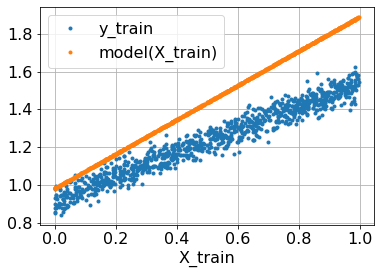

In [ ]:
if input_dim == output_dim == 1:
    fig = plt.figure()
    fig.clf()
    ax = fig.gca()
    ax.plot(training_set.input_data, training_set.output_data, '.')
    ax.plot(training_set.input_data, model.forward(training_set.input_data).detach().numpy(), '.')
    ax.grid(True)
    ax.set_xlabel('X_train')
    ax.legend(['y_train', 'model(X_train)'])

In [25]:
import torch.nn as nn
loss_fun = nn.MSELoss(reduction='mean')

In [26]:
x = torch.tensor(np.array([1, 2, 1]).astype('f'))
z = torch.tensor(np.array([0, 0, 0]).astype('f'))
loss_fun(x, z)

tensor(2.)

IndexError: list index out of range

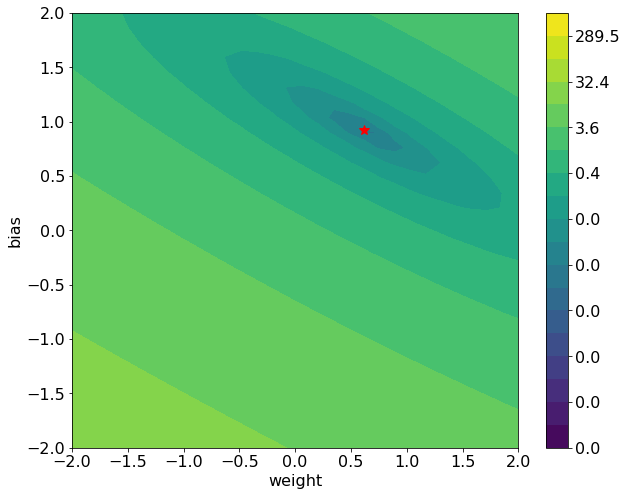

In [25]:
if input_dim == output_dim == 1:

    state_dict = model.state_dict()

    ww, bb = np.meshgrid(np.linspace(-2, 2, 30), np.linspace(-2, 2, 30))

    loss_values = 0 * ww
    for i in range(ww.shape[0]):
        for j in range(ww.shape[1]):
            state_dict['linear.weight'] = torch.tensor([[ww[i, j]]])
            state_dict['linear.bias'] = torch.tensor([bb[i, j]])
            model.load_state_dict(state_dict)
            loss_values[i, j] = loss_fun(model.forward(training_set.input_data),  training_set.output_data)

    fig = plt.figure(figsize=(10, 8))
    fig.clf()
    ax = fig.gca()
    levels = np.logspace(np.log(np.min(loss_values)), np.log(np.max(loss_values)), 20)
    c=ax.contourf(ww, bb, loss_values, levels=levels, norm=colors.LogNorm())
    plt.colorbar(c)
    ax.plot(A[0], b, 'r*', markersize=10)
    ax.set_ylabel('bias')
    ax.set_xlabel('weight')
    ax.legend(['(A, b)'])
    
    ax.grid(True)    

In [27]:
x = torch.randn(1, input_dim)
y =  torch.randn(1, output_dim)

model.zero_grad()
loss = loss_fun(model.forward(x),  y)
loss.backward()

In [28]:
if input_dim == output_dim == 1:
    print(model.linear.weight.grad)
    print(2 * x * (model.linear.weight * x + model.linear.bias - y))
    
    print(model.linear.bias.grad)
    print(2 * (model.linear.weight * x + model.linear.bias - y))

tensor([[1.8848]])
tensor([[1.8848]], grad_fn=<MulBackward0>)
tensor([-2.6991])
tensor([[-2.6991]], grad_fn=<MulBackward0>)


In [ ]:
if input_dim == output_dim == 1:

    num_iter = 200
    lr = 0.5

    train_hist = {}
    train_hist['weight'] = []
    train_hist['bias'] = []

    model.reset()
    state_dict = model.state_dict()

    for _ in range(num_iter):

        model.zero_grad()
        loss = loss_fun(model.forward(training_set.input_data), training_set.output_data)
        loss.backward()

        w = model.linear.weight.item()
        b = model.linear.bias.item()

        dw = model.linear.weight.grad.item()
        db = model.linear.bias.grad.item()

        state_dict['linear.weight'] += torch.tensor([-lr * dw])
        state_dict['linear.bias'] += torch.tensor([-lr * db])
        model.load_state_dict(state_dict)

        train_hist['weight'].append(w)
        train_hist['bias'].append(b)

    for label in train_hist:
        train_hist[label] = np.array(train_hist[label])

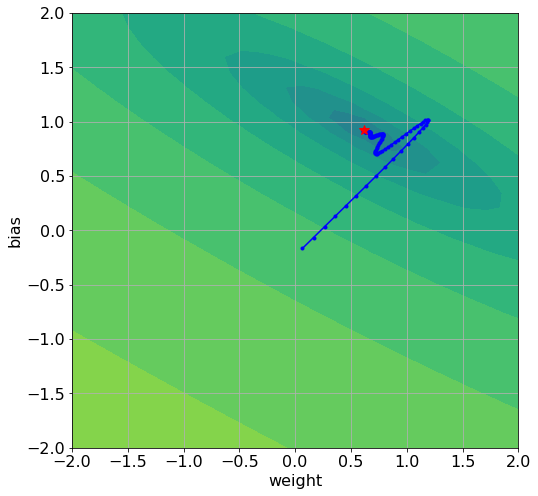

In [38]:
if input_dim == output_dim == 1:
    fig = plt.figure(figsize=(8, 8))
    fig.clf()
    ax = fig.gca()
    levels = np.logspace(np.log(np.min(loss_values)), np.log(np.max(loss_values)), 20)
    ax.contourf(ww, bb, loss_values, levels=levels, norm=colors.LogNorm())
    ax.set_xlabel('weight')
    ax.set_ylabel('bias')
    ax.grid(True)
    ax.set_xlim(-2, 2) 
    ax.set_ylim(-2, 2) 
    
    ax.plot(train_hist['weight'], train_hist['bias'], '.-b')
    ax.plot(A[0], b, 'r*', markersize=10)

    #ax.legend(['optim', '(A, b)'])

In [31]:
lr = 0.1
weight_decay = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
n_epochs = 100

In [ ]:
train_hist = {}
train_hist['loss'] = []

if input_dim == output_dim == 1:
    train_hist['weight'] = []
    train_hist['bias'] = []


model.reset()
model.train()

for epoch in range(n_epochs):
    for idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        loss = loss_fun(model.forward(batch[0]),  batch[1])
        loss.backward()
        optimizer.step()

        train_hist['loss'].append(loss.item())
        if input_dim == output_dim == 1:
            train_hist['weight'].append(model.linear.weight.item())
            train_hist['bias'].append(model.linear.bias.item())
        
        print('[Epoch %4d/%4d] [Batch %4d/%4d] Loss: % 2.2e' % (epoch + 1, n_epochs, 
                                                                idx + 1, len(train_loader), 
                                                                loss.item()))
        
model.eval()

[Epoch    1/ 100] [Batch    1/   9] Loss:  4.10e-02
[Epoch    1/ 100] [Batch    2/   9] Loss:  1.86e-02
[Epoch    1/ 100] [Batch    3/   9] Loss:  2.74e-02
[Epoch    1/ 100] [Batch    4/   9] Loss:  2.49e-02
[Epoch    1/ 100] [Batch    5/   9] Loss:  1.70e-02
[Epoch    1/ 100] [Batch    6/   9] Loss:  9.63e-03
[Epoch    1/ 100] [Batch    7/   9] Loss:  7.38e-03
[Epoch    1/ 100] [Batch    8/   9] Loss:  1.15e-02
[Epoch    1/ 100] [Batch    9/   9] Loss:  1.16e-02
[Epoch    2/ 100] [Batch    1/   9] Loss:  1.13e-02
[Epoch    2/ 100] [Batch    2/   9] Loss:  5.14e-03
[Epoch    2/ 100] [Batch    3/   9] Loss:  3.00e-03
[Epoch    2/ 100] [Batch    4/   9] Loss:  3.38e-03
[Epoch    2/ 100] [Batch    5/   9] Loss:  5.27e-03
[Epoch    2/ 100] [Batch    6/   9] Loss:  5.66e-03
[Epoch    2/ 100] [Batch    7/   9] Loss:  3.55e-03
[Epoch    2/ 100] [Batch    8/   9] Loss:  2.31e-03
[Epoch    2/ 100] [Batch    9/   9] Loss:  2.12e-03
[Epoch    3/ 100] [Batch    1/   9] Loss:  2.35e-03
[Epoch    3/

LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [36]:
if input_dim == output_dim == 1:
    n_test = 500
    X_test = np.random.rand(n_test, input_dim)
    y_pred = []

    state_dict = model.state_dict()

    for idx in range(len(train_hist['weight'])):
        state_dict['linear.weight'] = torch.tensor([[train_hist['weight'][idx]]])
        state_dict['linear.bias'] = torch.tensor([train_hist['bias'][idx]])
        model.load_state_dict(state_dict)

        y_pred.append(model.forward(torch.tensor(X_test.astype('f'))).detach().numpy())    